In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Sample Dataset
data = {
    'Study_Hours (X1)': [2, 4, 6, 8, 3, 7, 5, 9, 1, 10],
    'Sleep_Hours (X2)': [6, 7, 8, 7, 5, 8, 7, 9, 6, 8],
    'Exam_Score (Y)':   [55, 70, 85, 92, 62, 88, 78, 98, 48, 100]
}

df = pd.DataFrame(data)

# Features (X) & Target (Y) Split
X = df[['Study_Hours (X1)', 'Sleep_Hours (X2)']]
y = df['Exam_Score (Y)']

print("Input Data Head:")
print(X.head())

Input Data Head:
   Study_Hours (X1)  Sleep_Hours (X2)
0                 2                 6
1                 4                 7
2                 6                 8
3                 8                 7
4                 3                 5


In [14]:
# 1. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Feature Scaling
scaler = StandardScaler()

# Train data-la fit_transform & Test data-la transform
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nScaled X_train (First 3 rows):")
print(X_train_scaled[:8])


Scaled X_train (First 3 rows):
[[ 0.2847474   0.62554324]
 [-1.61356859 -1.04257207]
 [ 1.0440738   1.4596009 ]
 [-0.0949158   0.62554324]
 [ 1.42373699  0.62554324]
 [-1.23390539 -1.87662973]
 [ 0.6644106  -0.20851441]
 [-0.474579   -0.20851441]]


In [6]:
# 1. Model Train
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# 2. Predict on Test Data
y_pred = model.predict(X_test_scaled)

# 3. Calculate Metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\n--- EVALUATION METRICS ---")
print(f"Mean Squared Error (MSE) : {mse:.4f}")
print(f"R2 Score                  : {r2:.4f}")
print(f"Beta Coefficients (X1,X2) : {model.coef_}")
print(f"Intercept (Beta 0)        : {model.intercept_:.2f}")


--- EVALUATION METRICS ---
Mean Squared Error (MSE) : 16.1915
R2 Score                  : 0.8662
Beta Coefficients (X1,X2) : [13.03062222  2.5106618 ]
Intercept (Beta 0)        : 82.25


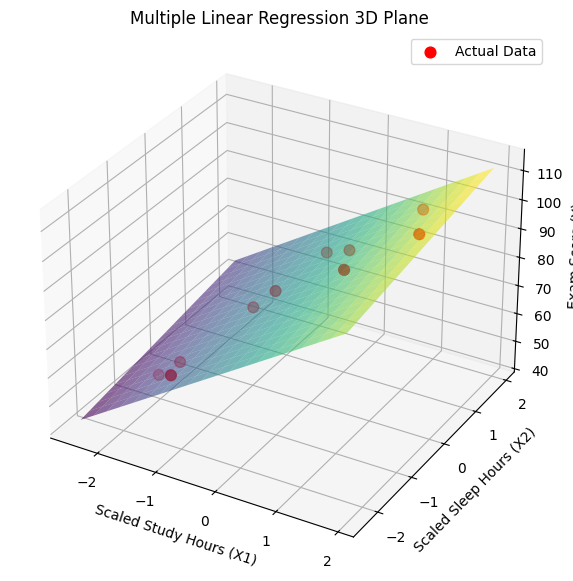

In [7]:
# 1. Transform entire X data to scaled space for plotting
X_scaled_all = scaler.transform(X)

# 2. Meshgrid creation for plane
x1_range = np.linspace(X_scaled_all[:, 0].min() - 0.5, X_scaled_all[:, 0].max() + 0.5, 20)
x2_range = np.linspace(X_scaled_all[:, 1].min() - 0.5, X_scaled_all[:, 1].max() + 0.5, 20)
X1_grid, X2_grid = np.meshgrid(x1_range, x2_range)

# 3. Predict Y values for mesh grid points
grid_points = np.c_[X1_grid.ravel(), X2_grid.ravel()]
Y_plane = model.predict(grid_points).reshape(X1_grid.shape)

# 4. Plot 3D Graph
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

# Data Points (Red Dots)
ax.scatter(X_scaled_all[:, 0], X_scaled_all[:, 1], y, color='red', s=60, label='Actual Data')

# Regression Surface Plane
ax.plot_surface(X1_grid, X2_grid, Y_plane, cmap='viridis', alpha=0.6)

# Graph Labels
ax.set_xlabel('Scaled Study Hours (X1)')
ax.set_ylabel('Scaled Sleep Hours (X2)')
ax.set_zlabel('Exam Score (Y)')
ax.set_title('Multiple Linear Regression 3D Plane')

plt.legend()
plt.show()